In [1]:
import xarray as xr

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import colormaps

import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
ds = xr.open_dataset("../example_data/NSIDC0081_SEAICE_PS_N25km_20230627_v2.0.nc")
ds

<xarray.Dataset> Size: 3MB
Dimensions:     (time: 1, y: 448, x: 304)
Coordinates:
  * time        (time) datetime64[ns] 8B 2023-06-27
  * y           (y) float64 4kB 5.838e+06 5.812e+06 ... -5.312e+06 -5.338e+06
  * x           (x) float64 2kB -3.838e+06 -3.812e+06 ... 3.712e+06 3.738e+06
Data variables:
    crs         |S1 1B ...
    F16_ICECON  (time, y, x) float64 1MB ...
    F17_ICECON  (time, y, x) float64 1MB ...
    F18_ICECON  (time, y, x) float64 1MB ...
Attributes: (12/49)
    title:                     Near-Real-Time DMSP SSMIS Daily Polar Gridded ...
    summary:                   This data set provides a Near-Real-Time (NRT) ...
    id:                        10.5067/YTTHO2FJQ97K
    license:                   Access Constraint: These data are freely, open...
    acknowledgment:            These data are produced and supported by the N...
    metadata_link:             https://doi.org/10.5067/YTTHO2FJQ97K
    ...                        ...
    geospatial_lat_units:      degrees_north
    geospatial_lon_units:      degrees_east
    product_version:           v2.0
    source:                    NOAA Comprehensive Large Array-data Stewardshi...
    instrument:                SSMIS > Special Sensor Microwave Imager/Sounde...
    platform:                  DMSP 5D-3/F16 > Defense Meteorological Satelli...

In [3]:
ds = ds.squeeze()
ds

<xarray.Dataset> Size: 3MB
Dimensions:     (y: 448, x: 304)
Coordinates:
  * y           (y) float64 4kB 5.838e+06 5.812e+06 ... -5.312e+06 -5.338e+06
  * x           (x) float64 2kB -3.838e+06 -3.812e+06 ... 3.712e+06 3.738e+06
    time        datetime64[ns] 8B 2023-06-27
Data variables:
    crs         |S1 1B ...
    F16_ICECON  (y, x) float64 1MB ...
    F17_ICECON  (y, x) float64 1MB ...
    F18_ICECON  (y, x) float64 1MB ...
Attributes: (12/49)
    title:                     Near-Real-Time DMSP SSMIS Daily Polar Gridded ...
    summary:                   This data set provides a Near-Real-Time (NRT) ...
    id:                        10.5067/YTTHO2FJQ97K
    license:                   Access Constraint: These data are freely, open...
    acknowledgment:            These data are produced and supported by the N...
    metadata_link:             https://doi.org/10.5067/YTTHO2FJQ97K
    ...                        ...
    geospatial_lat_units:      degrees_north
    geospatial_lon_units:      degrees_east
    product_version:           v2.0
    source:                    NOAA Comprehensive Large Array-data Stewardshi...
    instrument:                SSMIS > Special Sensor Microwave Imager/Sounde...
    platform:                  DMSP 5D-3/F16 > Defense Meteorological Satelli...

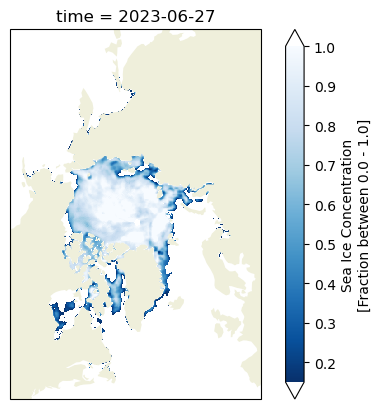

In [26]:
globe = ccrs.Globe(
    datum=None,
    ellipse=None,
    semimajor_axis=ds.crs.attrs["semi_major_axis"],
    inverse_flattening=ds.crs.attrs["inverse_flattening"],
)
projection = ccrs.Stereographic(
    central_latitude=ds.crs.attrs["latitude_of_projection_origin"],
    central_longitude=ds.crs.attrs["straight_vertical_longitude_from_pole"],
    true_scale_latitude=ds.crs.attrs["standard_parallel"],
    globe=globe,
)

norm = mcolors.Normalize(vmin=0.15, vmax=1, clip=False)
cmap = colormaps["Blues_r"]
cmap.set_extremes(under="white", over="white")
cmap.colorbar_extend = False

p = ds.F17_ICECON.plot(subplot_kws=dict(projection=projection), norm=norm, cmap=cmap)
p.axes.add_feature(cfeature.LAND, zorder=1)

In [27]:
import cmocean

ModuleNotFoundError: No module named 'cmocean'